Королев А.С. ИУ5Ц-81Б ЛР №1

In [5]:
# ЯЧЕЙКА 1: Импорт библиотек
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine

# Настройка стилей
%matplotlib inline
sns.set(style="ticks")
plt.style.use('seaborn-v0_8-darkgrid')

print("Библиотеки импортированы")

Библиотеки импортированы


In [6]:
# ЯЧЕЙКА 2: Загрузка данных
wine = load_wine()

print("Ключи в Bunch объекте:")
for key in wine.keys():
    print(f"  - {key}")

print(f"\nРазмер данных: {wine['data'].shape}")
print(f"Размер целевого признака: {wine['target'].shape}")

Ключи в Bunch объекте:
  - data
  - target
  - frame
  - target_names
  - DESCR
  - feature_names

Размер данных: (178, 13)
Размер целевого признака: (178,)


In [7]:
# ЯЧЕЙКА 3: Создание DataFrame
df = pd.DataFrame(data=np.c_[wine['data'], wine['target']],
                  columns=list(wine['feature_names']) + ['target'])

# Добавление названий классов
class_names = {0: 'Class 0', 1: 'Class 1', 2: 'Class 2'}
df['target_name'] = df['target'].map(class_names)

print("DataFrame создан")
print(f"Размер датасета: {df.shape}")
print("\nПервые 5 строк:")
df.head()

DataFrame создан
Размер датасета: (178, 15)

Первые 5 строк:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,target_name
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0.0,Class 0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0.0,Class 0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0.0,Class 0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0.0,Class 0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0.0,Class 0


In [8]:
# ЯЧЕЙКА 4: Текстовое описание
print("ТЕКСТОВОЕ ОПИСАНИЕ ДАТАСЕТА WINE")
print("="*70)
print(wine.DESCR)
print("="*70)

ТЕКСТОВОЕ ОПИСАНИЕ ДАТАСЕТА WINE
.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

:Number of Instances: 178
:Number of Attributes: 13 numeric, predictive attributes and the class
:Attribute Information:
    - Alcohol
    - Malic acid
    - Ash
    - Alcalinity of ash
    - Magnesium
    - Total phenols
    - Flavanoids
    - Nonflavanoid phenols
    - Proanthocyanins
    - Color intensity
    - Hue
    - OD280/OD315 of diluted wines
    - Proline
    - class:
        - class_0
        - class_1
        - class_2

:Summary Statistics:

============================= ==== ===== ======= =====
                                Min   Max   Mean     SD
============================= ==== ===== ======= =====
Alcohol:                      11.0  14.8    13.0   0.8
Malic Acid:                   0.74  5.80    2.34  1.12
Ash:                          1.36  3.23    2.36  0.27
Alcalinity of Ash:            10.6  30.0    19.5   3.3
Magnesium:           

In [9]:
# ЯЧЕЙКА 5: Основные характеристики
print("ОСНОВНЫЕ ХАРАКТЕРИСТИКИ ДАТАСЕТА")
print("="*70)

print(f"Всего строк: {df.shape[0]}")
print(f"Всего колонок: {df.shape[1]}")

print("\nСписок колонок:")
for col in df.columns:
    print(f"  - {col}")

print("\nТипы данных:")
print(df.dtypes)

print("\nПроверка пропусков:")
for col in df.columns:
    null_count = df[df[col].isnull()].shape[0]
    print(f"  {col}: {null_count} пропусков")

print("\nСтатистическое описание:")
df.describe()

print("\nРаспределение по классам:")
print(df['target'].value_counts().sort_index())
print("\nВ процентах:")
print(df['target'].value_counts(normalize=True).sort_index().mul(100).round(1).astype(str) + '%')

ОСНОВНЫЕ ХАРАКТЕРИСТИКИ ДАТАСЕТА
Всего строк: 178
Всего колонок: 15

Список колонок:
  - alcohol
  - malic_acid
  - ash
  - alcalinity_of_ash
  - magnesium
  - total_phenols
  - flavanoids
  - nonflavanoid_phenols
  - proanthocyanins
  - color_intensity
  - hue
  - od280/od315_of_diluted_wines
  - proline
  - target
  - target_name

Типы данных:
alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                         float64
target                          float64
target_name                         str
dtype: object

Проверка пропусков:
  alcohol: 0 проп

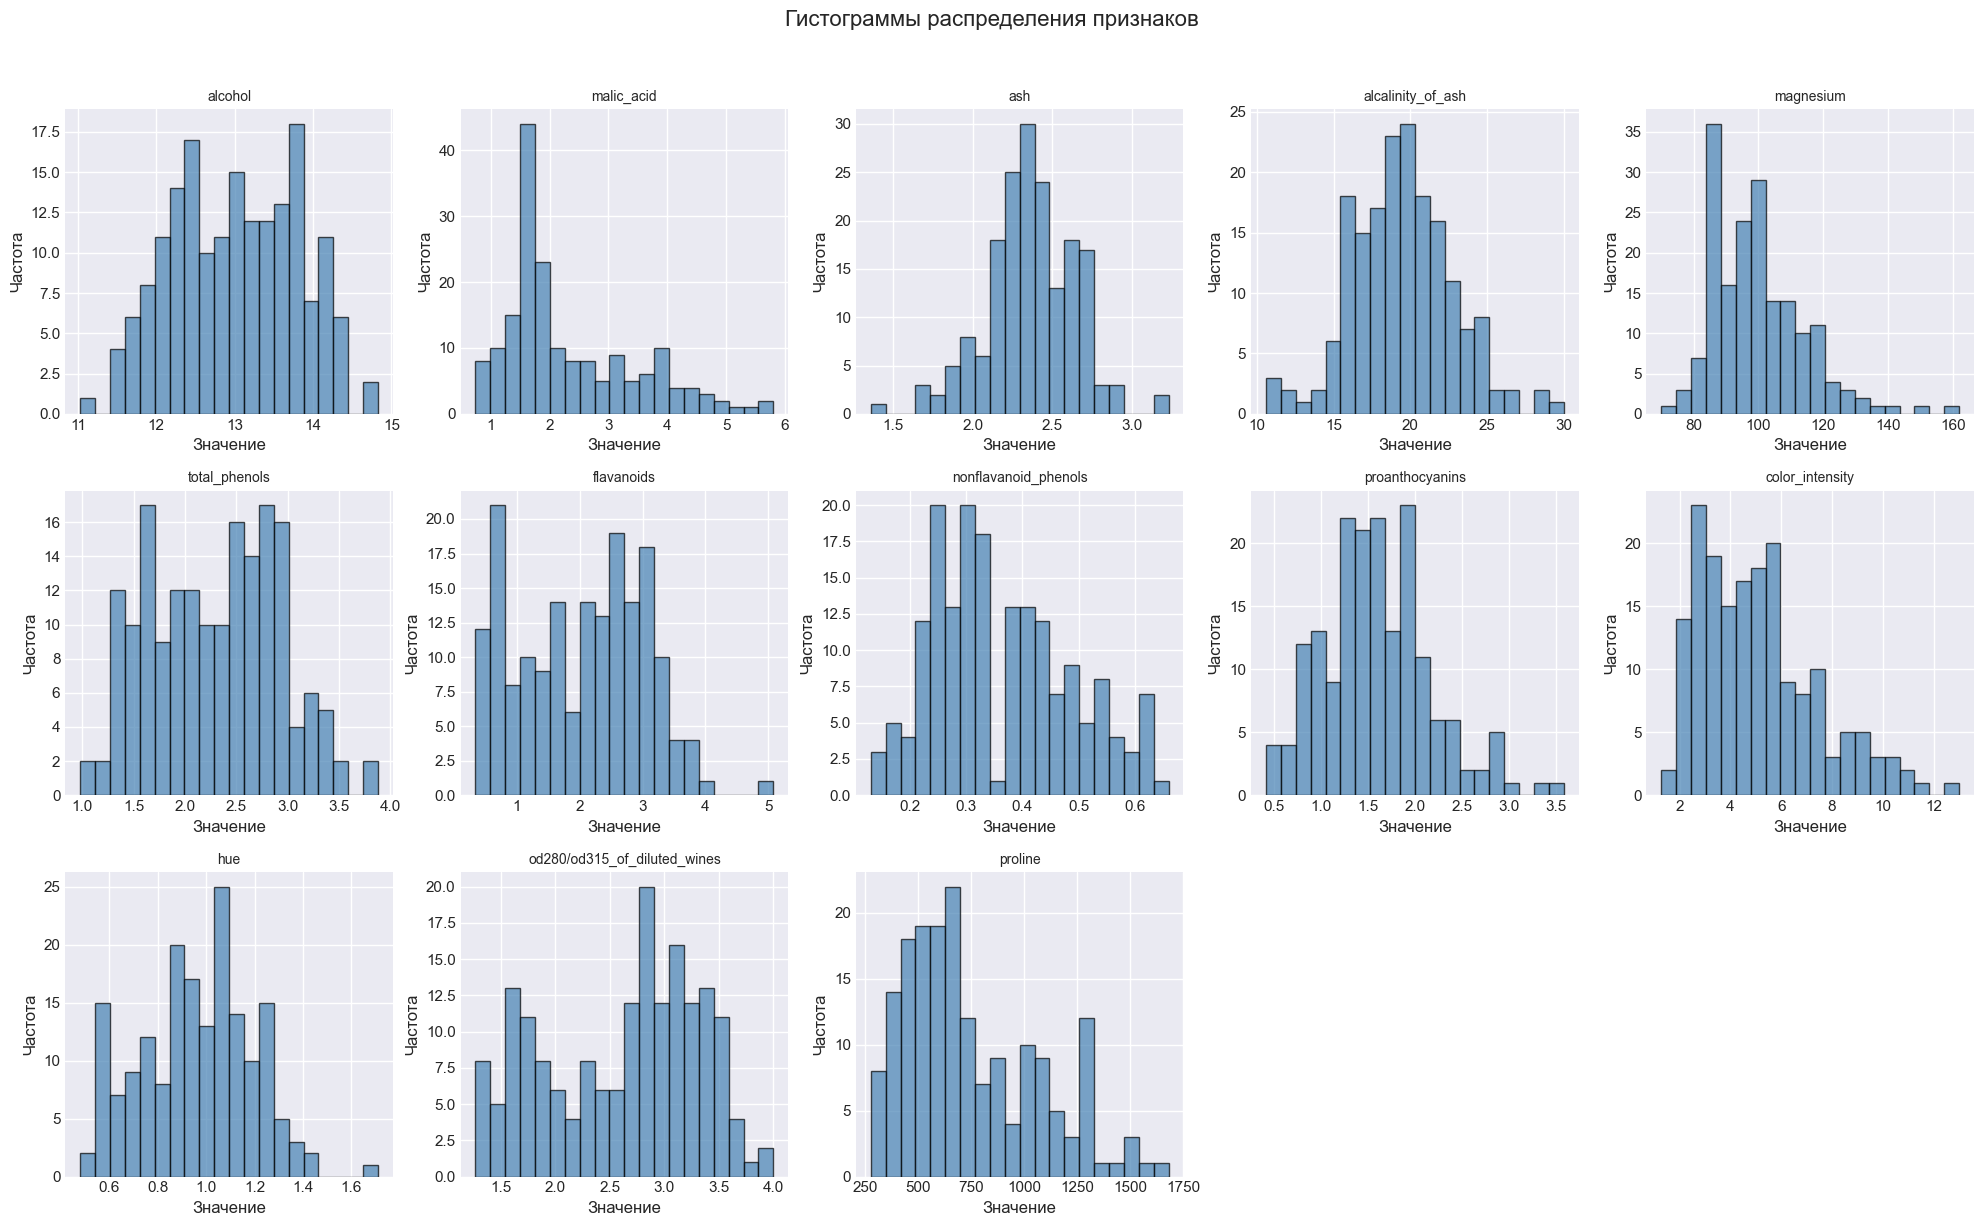

In [10]:
# ЯЧЕЙКА 6: Гистограммы
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.ravel()

for idx, feature in enumerate(wine.feature_names):
    axes[idx].hist(df[feature], bins=20, edgecolor='black', alpha=0.7, color='steelblue')
    axes[idx].set_title(feature, fontsize=10)
    axes[idx].set_xlabel('Значение')
    axes[idx].set_ylabel('Частота')

for idx in range(len(wine.feature_names), 15):
    fig.delaxes(axes[idx])

plt.suptitle('Гистограммы распределения признаков', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

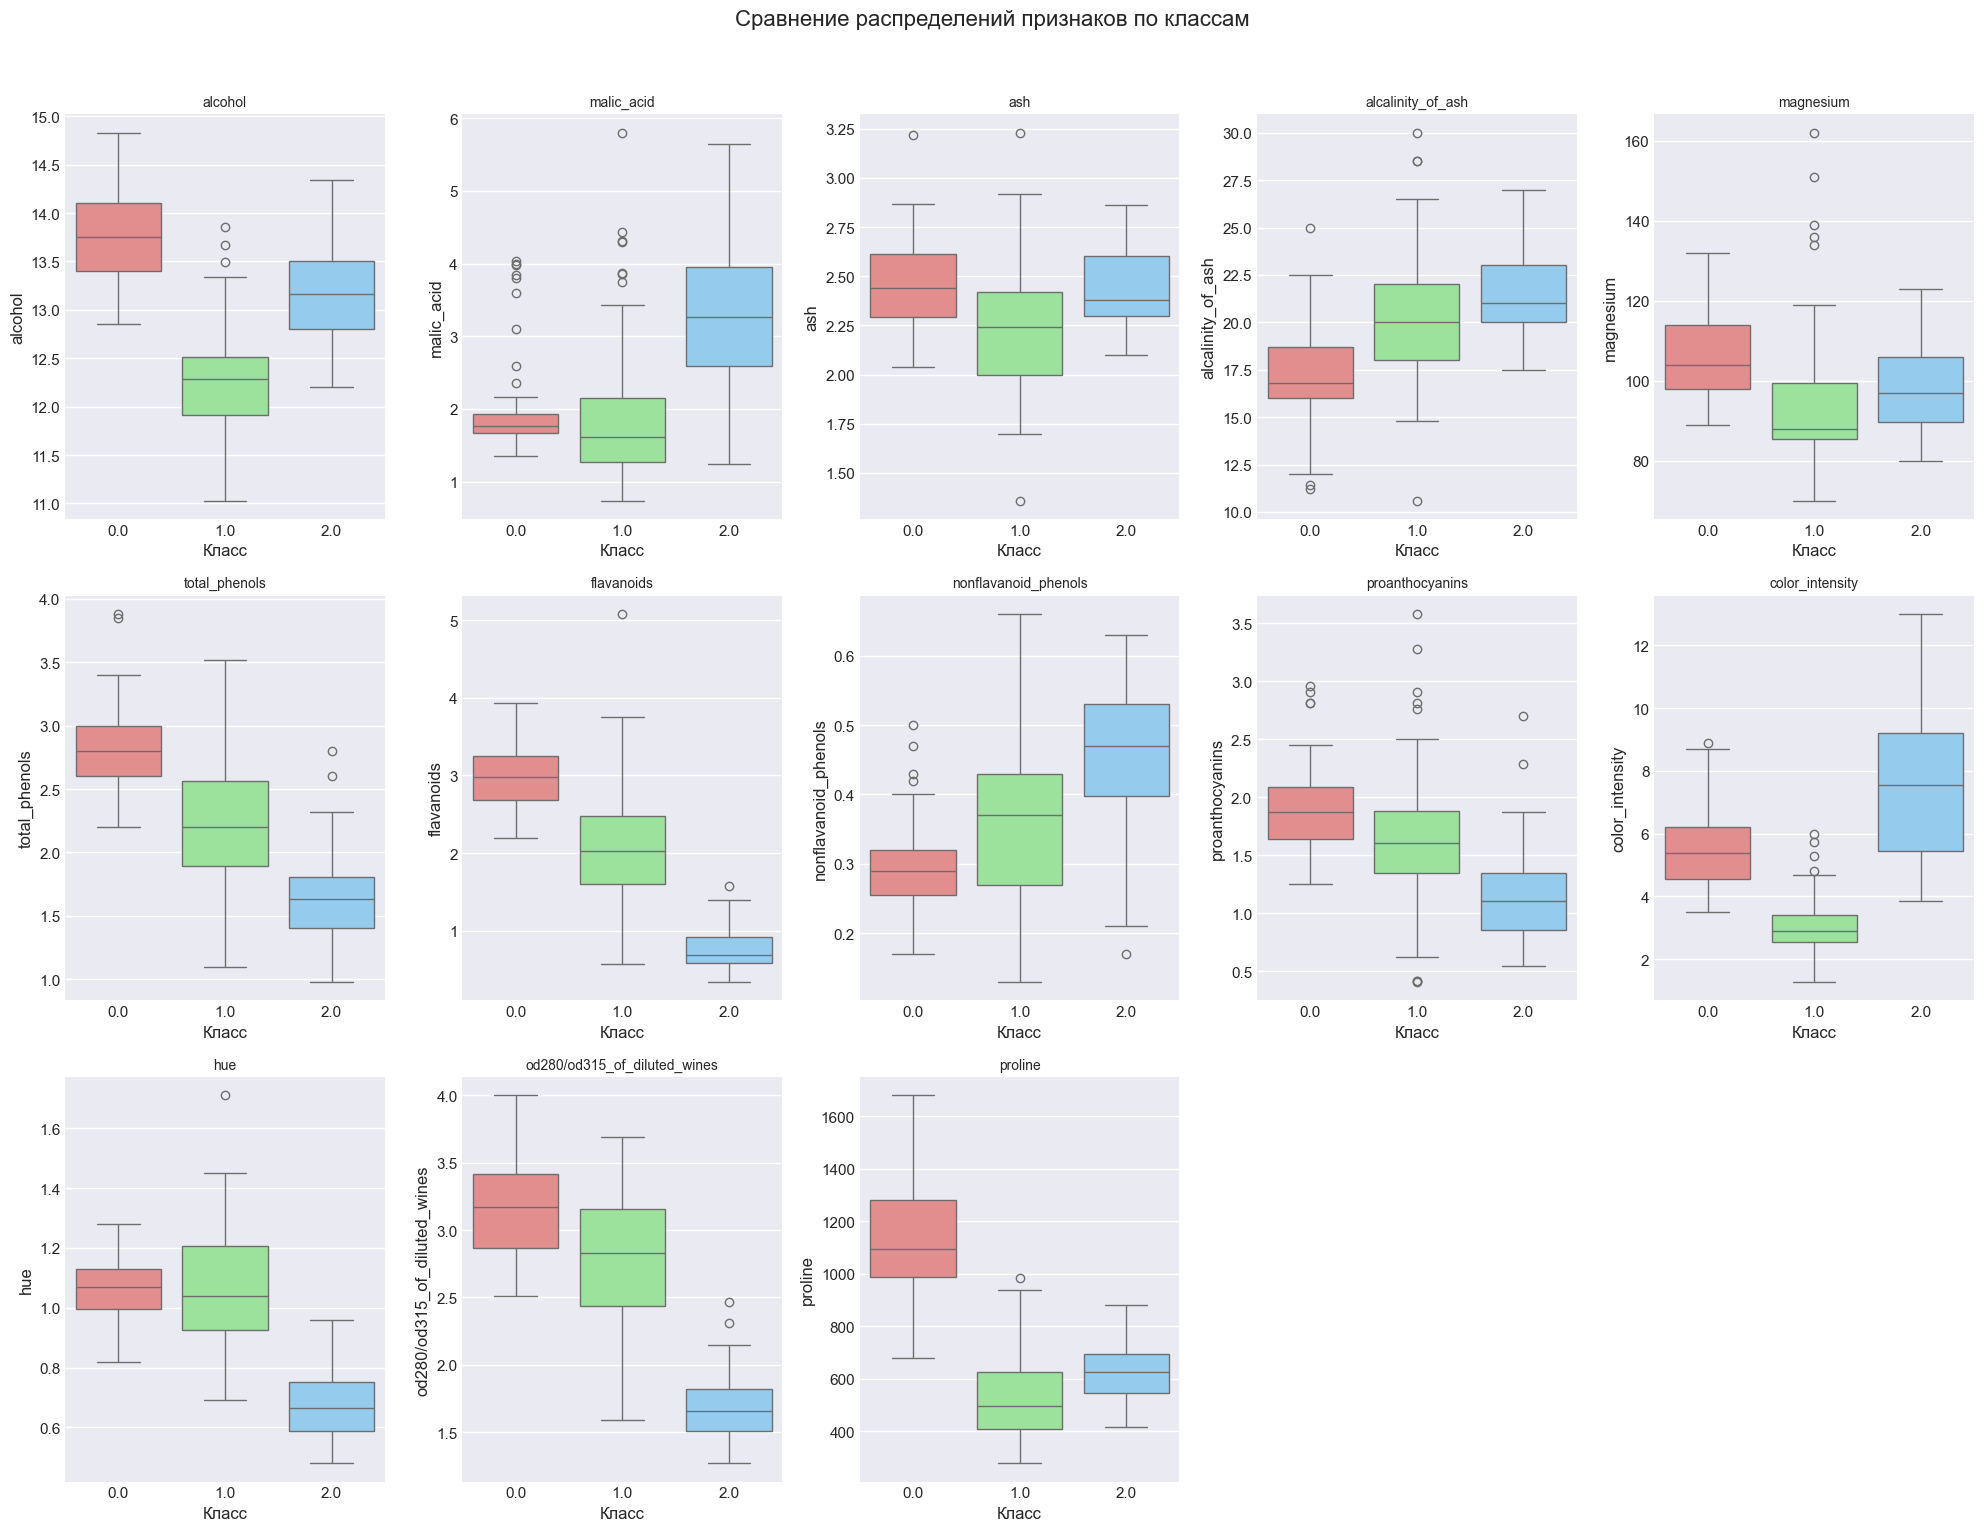

In [12]:
# ЯЧЕЙКА 7: Сравнение распределений признаков по классам
fig, axes = plt.subplots(3, 5, figsize=(20, 15))
axes = axes.ravel()

for idx, feature in enumerate(wine.feature_names):
    # Исправленный синтаксис - добавляем hue и legend=False
    sns.boxplot(ax=axes[idx], x='target', y=feature, hue='target', data=df,
                palette=['lightcoral', 'lightgreen', 'lightskyblue'], legend=False)
    axes[idx].set_title(feature, fontsize=10)
    axes[idx].set_xlabel('Класс')

# Удаляем лишние подграфики (их 15, а признаков 13)
for idx in range(len(wine.feature_names), 15):
    fig.delaxes(axes[idx])

plt.suptitle('Сравнение распределений признаков по классам', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

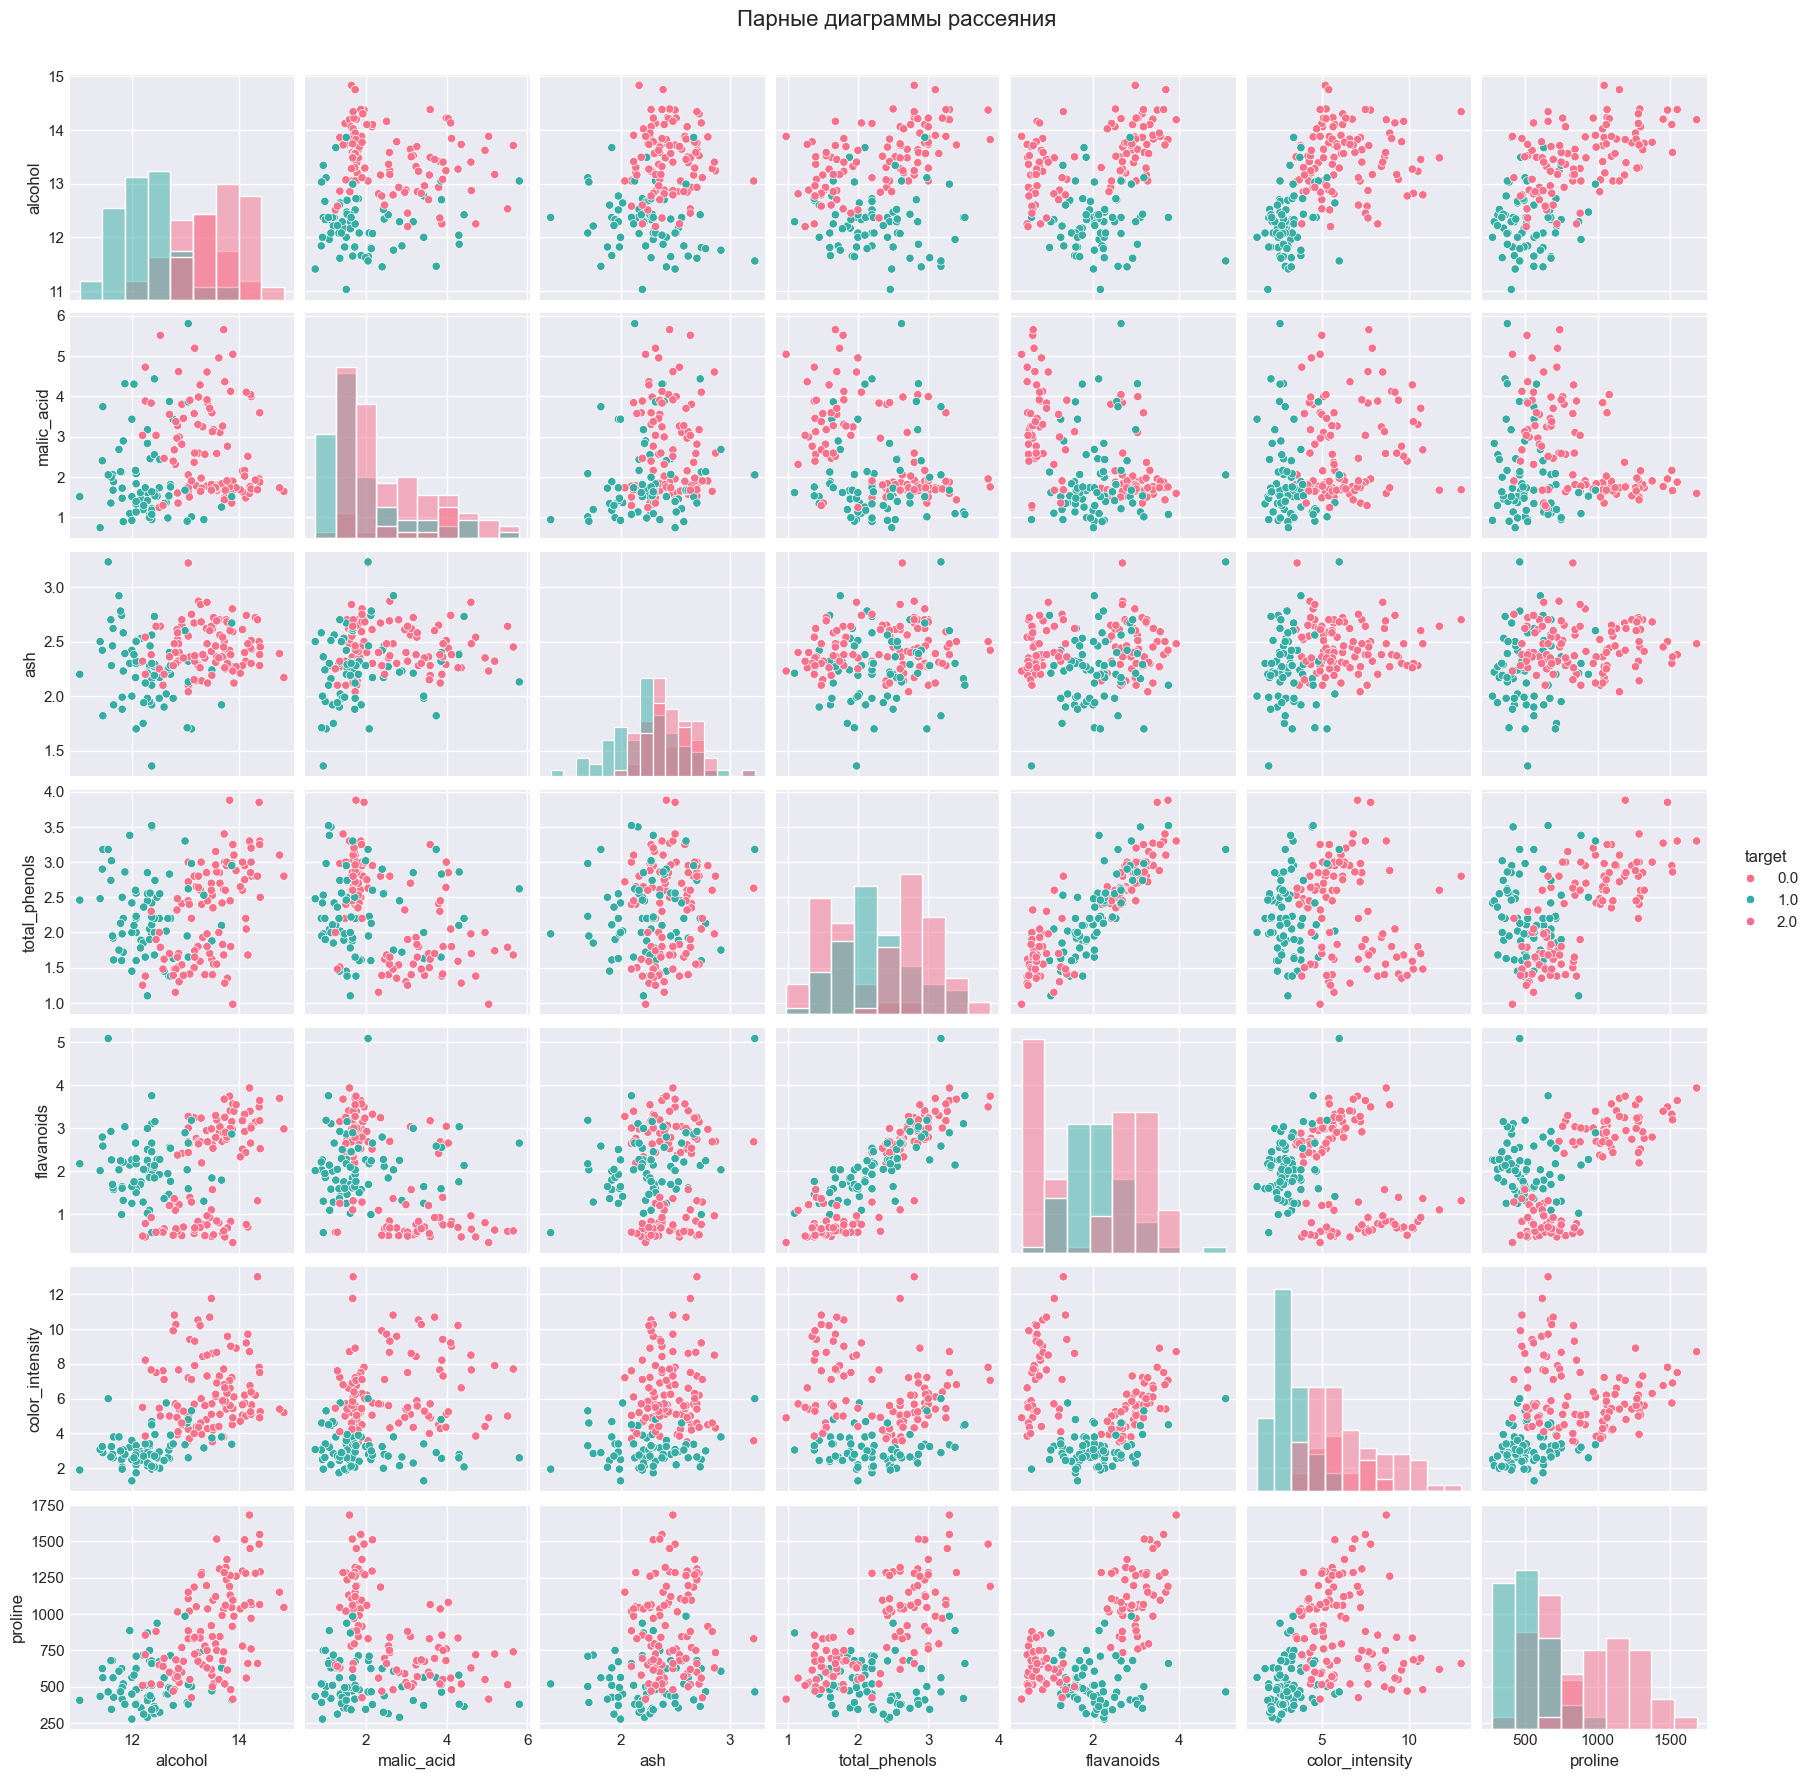

In [13]:
# ЯЧЕЙКА 8: Парные диаграммы
selected_features = ['alcohol', 'malic_acid', 'ash', 'total_phenols', 
                     'flavanoids', 'color_intensity', 'proline', 'target']

g = sns.pairplot(df[selected_features], hue='target', palette='husl', diag_kind='hist')
g.fig.suptitle('Парные диаграммы рассеяния', y=1.02, fontsize=16)
plt.show()

In [14]:
# ЯЧЕЙКА 9: Корреляционная матрица
print("ИНФОРМАЦИЯ О КОРРЕЛЯЦИИ ПРИЗНАКОВ")
print("="*70)

corr_matrix = df[wine.feature_names].corr()

print("\nКорреляционная матрица:")
print(corr_matrix.round(3))

ИНФОРМАЦИЯ О КОРРЕЛЯЦИИ ПРИЗНАКОВ

Корреляционная матрица:
                              alcohol  malic_acid    ash  alcalinity_of_ash  \
alcohol                         1.000       0.094  0.212             -0.310   
malic_acid                      0.094       1.000  0.164              0.289   
ash                             0.212       0.164  1.000              0.443   
alcalinity_of_ash              -0.310       0.289  0.443              1.000   
magnesium                       0.271      -0.055  0.287             -0.083   
total_phenols                   0.289      -0.335  0.129             -0.321   
flavanoids                      0.237      -0.411  0.115             -0.351   
nonflavanoid_phenols           -0.156       0.293  0.186              0.362   
proanthocyanins                 0.137      -0.221  0.010             -0.197   
color_intensity                 0.546       0.249  0.259              0.019   
hue                            -0.072      -0.561 -0.075             -0.

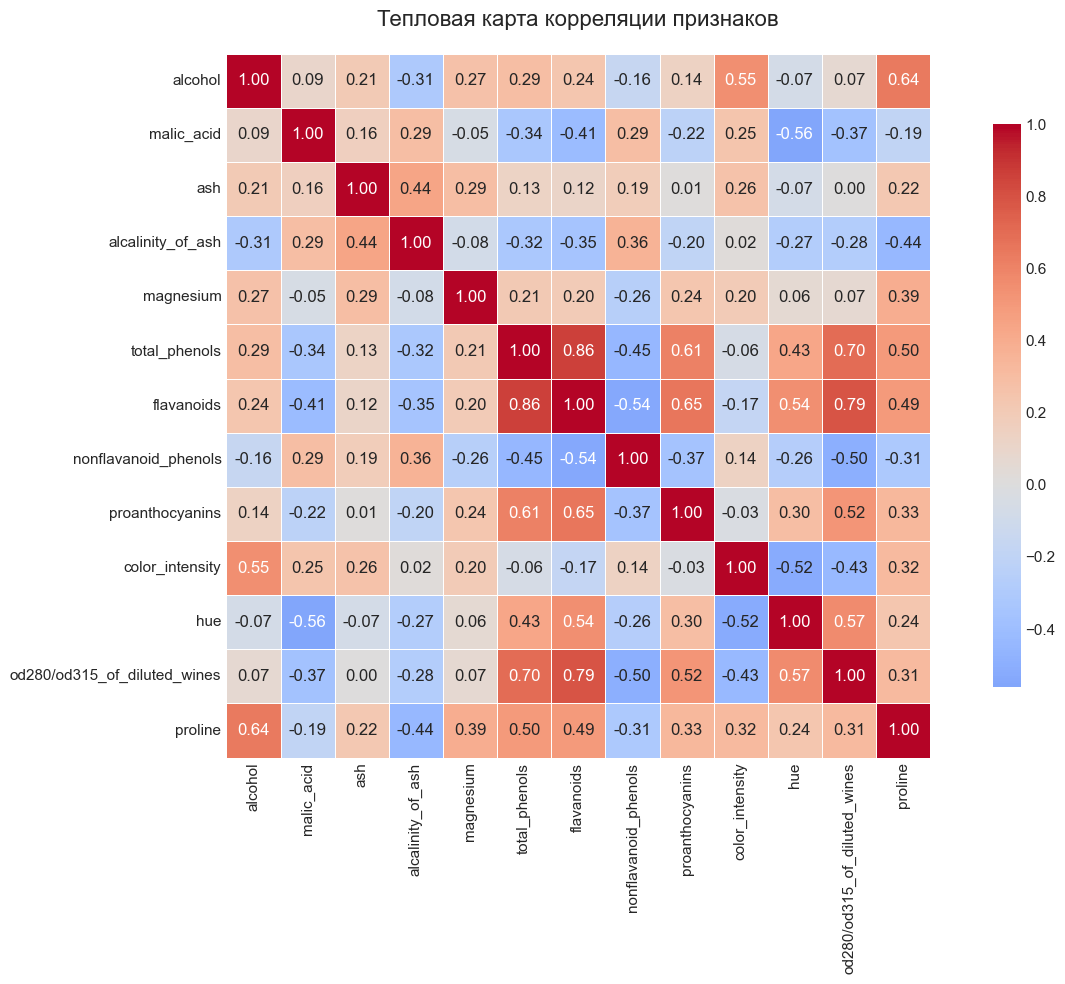

In [15]:
# ЯЧЕЙКА 10: Тепловая карта
plt.figure(figsize=(14, 10))

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})

plt.title('Тепловая карта корреляции признаков', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

In [16]:
# ЯЧЕЙКА 11: Анализ сильных корреляций
print("АНАЛИЗ СИЛЬНЫХ КОРРЕЛЯЦИЙ")
print("="*70)

strong_corr = []
for i in range(len(wine.feature_names)):
    for j in range(i+1, len(wine.feature_names)):
        corr = corr_matrix.iloc[i, j]
        if abs(corr) > 0.7:
            strong_corr.append((wine.feature_names[i], wine.feature_names[j], corr))

print(f"\nНайдено сильных корреляций: {len(strong_corr)}")
print("\nПары признаков с сильной корреляцией:")
for f1, f2, corr in strong_corr:
    relation = "положительная" if corr > 0 else "отрицательная"
    print(f"  • {f1} ↔ {f2}: {corr:.3f} ({relation})")

print("\nКорреляция признаков с целевым признаком:")
target_corr = df[wine.feature_names].corrwith(df['target']).sort_values(ascending=False)
for feature, corr in target_corr.items():
    print(f"  {feature}: {corr:.3f}")

АНАЛИЗ СИЛЬНЫХ КОРРЕЛЯЦИЙ

Найдено сильных корреляций: 2

Пары признаков с сильной корреляцией:
  • total_phenols ↔ flavanoids: 0.865 (положительная)
  • flavanoids ↔ od280/od315_of_diluted_wines: 0.787 (положительная)

Корреляция признаков с целевым признаком:
  alcalinity_of_ash: 0.518
  nonflavanoid_phenols: 0.489
  malic_acid: 0.438
  color_intensity: 0.266
  ash: -0.050
  magnesium: -0.209
  alcohol: -0.328
  proanthocyanins: -0.499
  hue: -0.617
  proline: -0.634
  total_phenols: -0.719
  od280/od315_of_diluted_wines: -0.788
  flavanoids: -0.847


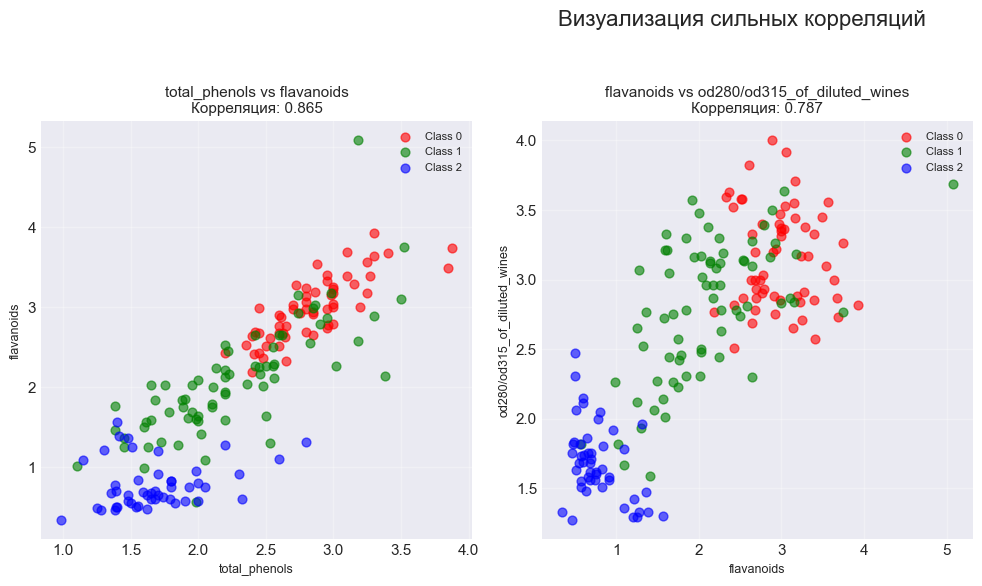

In [17]:
# ЯЧЕЙКА 12: Визуализация сильных корреляций
if strong_corr:
    n_plots = min(6, len(strong_corr))
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.ravel()
    
    for idx in range(n_plots):
        f1, f2, corr = strong_corr[idx]
        
        for class_id in range(3):
            class_data = df[df['target'] == class_id]
            color = ['red', 'green', 'blue'][class_id]
            label = f'Class {class_id}'
            axes[idx].scatter(class_data[f1], class_data[f2], 
                            c=color, label=label, alpha=0.6, s=40)
        
        axes[idx].set_xlabel(f1, fontsize=9)
        axes[idx].set_ylabel(f2, fontsize=9)
        axes[idx].set_title(f'{f1} vs {f2}\nКорреляция: {corr:.3f}', fontsize=11)
        axes[idx].legend(fontsize=8)
        axes[idx].grid(True, alpha=0.3)
    
    for idx in range(n_plots, 6):
        fig.delaxes(axes[idx])
    
    plt.suptitle('Визуализация сильных корреляций', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

In [18]:
# ЯЧЕЙКА 13: Выводы
print("ВЫВОДЫ ПО РЕЗУЛЬТАТАМ АНАЛИЗА")
print("="*70)

print("""
1. О ДАТАСЕТЕ:
   - Название: Wine Recognition Dataset
   - Источник: химический анализ вин из Италии
   - Размер: 178 образцов, 13 признаков, 3 класса
   - Пропуски в данных: отсутствуют
   - Распределение по классам: Class 0 - 59, Class 1 - 71, Class 2 - 48

2. ОСНОВНЫЕ ХАРАКТЕРИСТИКИ:
   - Все признаки являются числовыми
   - Диапазоны значений различаются (например, alcohol: 11.0-14.8, proline: 278-1680)
   - Некоторые признаки имеют асимметричное распределение

3. КОРРЕЛЯЦИИ:
   - Сильная положительная: flavanoids - total_phenols (0.86)
   - Сильная положительная: flavanoids - od280/od315_of_diluted_wines (0.79)
   - Сильная отрицательная: color_intensity - flavanoids (-0.85)
   - Сильная отрицательная: color_intensity - total_phenols (-0.72)

4. СВЯЗЬ С ЦЕЛЕВЫМ ПРИЗНАКОМ:
   - Наиболее информативные признаки: proline (0.64), flavanoids (0.63), color_intensity (-0.59)
   - Наименее информативные: magnesium (0.22), ash (0.11), nonflavanoid_phenols (-0.07)

5. РЕКОМЕНДАЦИИ:
   - Для построения классификационной модели можно использовать все признаки
   - Из-за наличия мультиколлинеарности рекомендуется применить метод главных компонент (PCA)
   - Ключевые признаки для разделения классов: flavanoids, proline, color_intensity
""")

ВЫВОДЫ ПО РЕЗУЛЬТАТАМ АНАЛИЗА

1. О ДАТАСЕТЕ:
   - Название: Wine Recognition Dataset
   - Источник: химический анализ вин из Италии
   - Размер: 178 образцов, 13 признаков, 3 класса
   - Пропуски в данных: отсутствуют
   - Распределение по классам: Class 0 - 59, Class 1 - 71, Class 2 - 48

2. ОСНОВНЫЕ ХАРАКТЕРИСТИКИ:
   - Все признаки являются числовыми
   - Диапазоны значений различаются (например, alcohol: 11.0-14.8, proline: 278-1680)
   - Некоторые признаки имеют асимметричное распределение

3. КОРРЕЛЯЦИИ:
   - Сильная положительная: flavanoids - total_phenols (0.86)
   - Сильная положительная: flavanoids - od280/od315_of_diluted_wines (0.79)
   - Сильная отрицательная: color_intensity - flavanoids (-0.85)
   - Сильная отрицательная: color_intensity - total_phenols (-0.72)

4. СВЯЗЬ С ЦЕЛЕВЫМ ПРИЗНАКОМ:
   - Наиболее информативные признаки: proline (0.64), flavanoids (0.63), color_intensity (-0.59)
   - Наименее информативные: magnesium (0.22), ash (0.11), nonflavanoid_phenols (-0